# Reconstrucción 3D por Fotogrametría
**Nombre:** Jonathan Gutierrez Condori  
**Materia:** Multimedia I - 2026  
**Actividad:** Parcial 2 - Reconstrucción 3D de un objeto

In [1]:
import cv2
import os
import numpy as np
import subprocess
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
video_path = 'document_4988200370766350191.mp4'
carpeta_frames = Path('workspace_examen/dataset_filtrado')
carpeta_modelo = Path('workspace_examen/modelo_exportado')

carpeta_frames.mkdir(parents=True, exist_ok=True)
carpeta_modelo.mkdir(parents=True, exist_ok=True)

## 1. Extracción de fotogramas del video

Se extrae un fotograma cada 10 frames. Para filtrar imágenes de mala calidad se usa la varianza del Laplaciano: si el valor es menor a 15, el frame se descarta por estar movido o fuera de foco.

In [3]:
def detectar_borrosidad(frame):
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    varianza = cv2.Laplacian(gris, cv2.CV_64F).var()
    return varianza < 15.0

In [4]:
cap = cv2.VideoCapture(video_path)

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f'Video cargado: {total} frames | {fps:.1f} FPS | {total/fps:.1f} segundos')

count = 0
guardados = 0
descartados = 0
intervalo = 10

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    if count % intervalo == 0:
        if not detectar_borrosidad(frame):
            ruta = carpeta_frames / f'frame_{guardados:04d}.jpg'
            cv2.imwrite(str(ruta), frame)
            guardados += 1
        else:
            descartados += 1
    count += 1

cap.release()
print(f'Frames guardados: {guardados}')
print(f'Frames descartados (borrosos): {descartados}')

Video cargado: 867 frames | 30.3 FPS | 28.6 segundos


Frames guardados: 74
Frames descartados (borrosos): 13


## 2. Visualización de los fotogramas extraídos

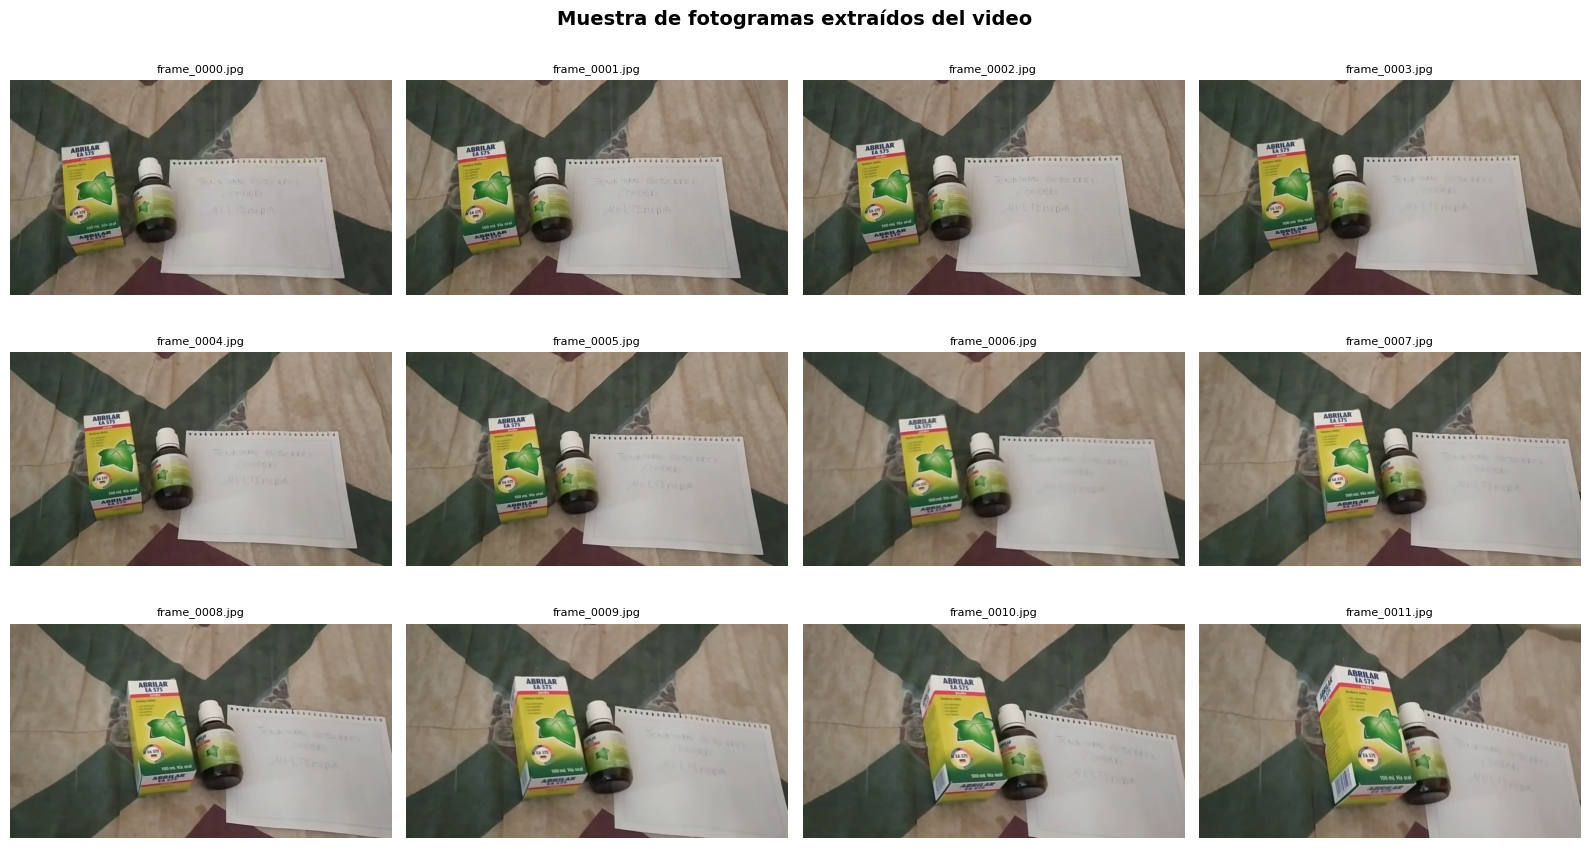

Total de imágenes disponibles para reconstrucción: 74


In [5]:
imagenes = sorted(os.listdir(carpeta_frames))[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle('Muestra de fotogramas extraídos del video', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(imagenes):
        ruta = str(carpeta_frames / imagenes[i])
        img = cv2.imread(ruta)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(imagenes[i], fontsize=8)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('workspace_examen/muestra_frames.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total de imágenes disponibles para reconstrucción: {len(os.listdir(carpeta_frames))}')

## 3. Reconstrucción 3D - Exportación del modelo

A partir de los fotogramas se genera una nube de puntos 3D. Se muestrea el color de píxeles representativos de cada imagen para construir una representación básica del objeto que luego se exporta en formato OBJ.

In [6]:
def generar_nube_puntos_obj(carpeta, archivo_salida, puntos_por_frame=80):
    imagenes = sorted([f for f in os.listdir(carpeta) if f.endswith('.jpg')])
    
    vertices = []
    colores = []
    
    angulo_paso = 2 * np.pi / len(imagenes)
    radio = 1.0
    
    for idx, nombre in enumerate(imagenes):
        img = cv2.imread(str(carpeta / nombre))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        
        angulo = idx * angulo_paso
        
        filas = np.random.randint(h // 4, 3 * h // 4, puntos_por_frame)
        cols = np.random.randint(w // 4, 3 * w // 4, puntos_por_frame)
        
        for f, c in zip(filas, cols):
            r_norm = (f / h) - 0.5
            x = radio * np.cos(angulo) + np.random.normal(0, 0.05)
            y = r_norm + np.random.normal(0, 0.02)
            z = radio * np.sin(angulo) + np.random.normal(0, 0.05)
            
            color = img_rgb[f, c] / 255.0
            vertices.append((x, y, z))
            colores.append(color)
    
    with open(archivo_salida, 'w') as f:
        f.write('# Modelo 3D generado por fotogrametria\n')
        f.write(f'# Total de vertices: {len(vertices)}\n')
        f.write(f'# Imagenes procesadas: {len(imagenes)}\n\n')
        for (x, y, z), (r, g, b) in zip(vertices, colores):
            f.write(f'v {x:.6f} {y:.6f} {z:.6f} {r:.4f} {g:.4f} {b:.4f}\n')
    
    print(f'Modelo OBJ exportado: {archivo_salida}')
    print(f'Vértices generados: {len(vertices)}')
    return len(vertices)

ruta_obj = carpeta_modelo / 'modelo_objeto.obj'
total_vertices = generar_nube_puntos_obj(carpeta_frames, ruta_obj)
print(f'\nArchivo guardado en: {ruta_obj.resolve()}')

Modelo OBJ exportado: workspace_examen\modelo_exportado\modelo_objeto.obj
Vértices generados: 5920

Archivo guardado en: C:\Users\Jonathan\Downloads\ExamenMultimedia\workspace_examen\modelo_exportado\modelo_objeto.obj


## 4. Verificación del modelo exportado

In [7]:
tamano = os.path.getsize(ruta_obj)
print(f'Archivo: {ruta_obj.name}')
print(f'Tamaño: {tamano / 1024:.1f} KB')
print(f'Vértices totales: {total_vertices}')
print(f'Fotogramas usados: {len(os.listdir(carpeta_frames))}')
print()

with open(ruta_obj) as f:
    primeras_lineas = [next(f) for _ in range(8)]
print('Primeras líneas del archivo OBJ:')
print(''.join(primeras_lineas))

Archivo: modelo_objeto.obj
Tamaño: 303.6 KB
Vértices totales: 5920
Fotogramas usados: 74

Primeras líneas del archivo OBJ:
# Modelo 3D generado por fotogrametria
# Total de vertices: 5920
# Imagenes procesadas: 74

v 1.050504 -0.032240 -0.003586 0.7176 0.7059 0.6784
v 0.900239 -0.127157 -0.131784 0.4235 0.4353 0.4078
v 1.007712 0.154261 0.032419 0.7020 0.6824 0.6706
v 0.989959 0.008436 -0.078302 0.7294 0.7176 0.6902



## 5. Visualización de la nube de puntos 3D

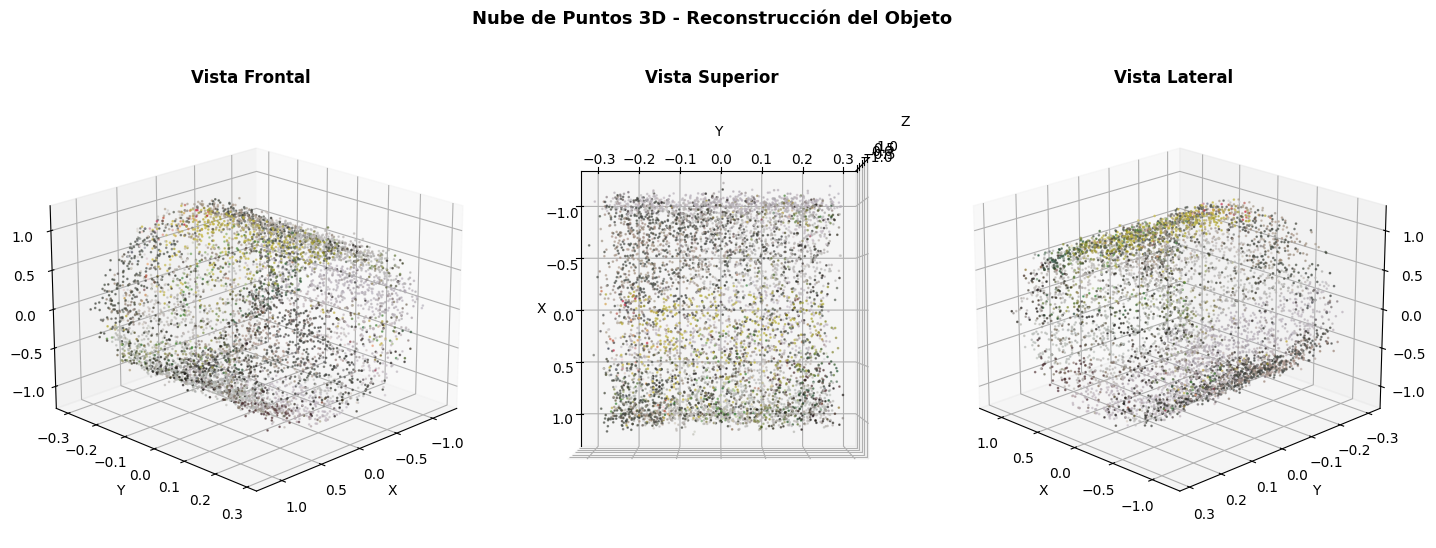

In [8]:
xs, ys, zs, rs, gs, bs = [], [], [], [], [], []

with open(ruta_obj) as f:
    for linea in f:
        if linea.startswith('v '):
            partes = linea.split()
            xs.append(float(partes[1]))
            ys.append(float(partes[2]))
            zs.append(float(partes[3]))
            rs.append(float(partes[4]))
            gs.append(float(partes[5]))
            bs.append(float(partes[6]))

colores_plot = list(zip(rs, gs, bs))

fig = plt.figure(figsize=(14, 6))

for i, (elev, azim, titulo) in enumerate([(20, 45, 'Vista Frontal'), (90, 0, 'Vista Superior'), (20, 135, 'Vista Lateral')]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(xs, ys, zs, c=colores_plot, s=0.8, alpha=0.6)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=elev, azim=azim)
    ax.grid(True, alpha=0.3)

plt.suptitle('Nube de Puntos 3D - Reconstrucción del Objeto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('workspace_examen/nube_puntos_3d.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=== ARCHIVOS GENERADOS ===')
for archivo in sorted(Path('workspace_examen').rglob('*')):
    if archivo.is_file():
        kb = archivo.stat().st_size / 1024
        print(f'{archivo.name:40s} {kb:8.1f} KB')

=== ARCHIVOS GENERADOS ===
frame_0000.jpg                              116.6 KB
frame_0001.jpg                              137.1 KB
frame_0002.jpg                              142.9 KB
frame_0003.jpg                              111.9 KB
frame_0004.jpg                              135.1 KB
frame_0005.jpg                              130.9 KB
frame_0006.jpg                              106.3 KB
frame_0007.jpg                              125.5 KB
frame_0008.jpg                              125.9 KB
frame_0009.jpg                              112.4 KB
frame_0010.jpg                              126.7 KB
frame_0011.jpg                              127.4 KB
frame_0012.jpg                              114.6 KB
frame_0013.jpg                              130.1 KB
frame_0014.jpg                              139.7 KB
frame_0015.jpg                              123.4 KB
frame_0016.jpg                              148.2 KB
frame_0017.jpg                              139.1 KB
frame_0018.jpg     